# Speech Emotion Classification Using LSTM

## Objective

The objective of this experiment is to build an LSTM-based speech emotion classification model.

The audio signals are converted into sequential MFCC features and provided as input to an LSTM network to classify different emotional states.

The complete pipeline includes:
- Dataset analysis
- Audio preprocessing
- MFCC feature extraction
- LSTM model training
- Performance evaluation

In [1]:
import os
import random

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns


import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Dataset Description

## Dataset Name

Toronto Emotional Speech Set (TESS)


## Dataset Source

TESS is an open-source speech emotion dataset containing recordings of spoken words with different emotional expressions.

The dataset consists of two speakers and seven emotion categories.


## Reason for Selection

TESS was selected because:
- It has clean emotional speech recordings.
- It requires less storage compared to larger datasets.
- The dataset is suitable for sequence-based models such as LSTM.
- The audio samples are clearly labeled.

In [3]:
DATASET_PATH = r"D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data"


files = []
labels = []


for folder in os.listdir(DATASET_PATH):

    folder_path = os.path.join(
        DATASET_PATH,
        folder
    )


    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if file.endswith(".wav"):

                files.append(
                    os.path.join(
                        folder_path,
                        file
                    )
                )


                # Extract emotion from folder name
                emotion = folder.split("_")[-1].lower()


                labels.append(
                    emotion
                )



df = pd.DataFrame({

    "path": files,

    "emotion": labels

})


print("Total Samples:", len(df))

df.head()

Total Samples: 2800


,path,emotion
0,D:\onboarding-audio\task5\archive\TESS Toronto...,angry
1,D:\onboarding-audio\task5\archive\TESS Toronto...,angry
2,D:\onboarding-audio\task5\archive\TESS Toronto...,angry
3,D:\onboarding-audio\task5\archive\TESS Toronto...,angry
4,D:\onboarding-audio\task5\archive\TESS Toronto...,angry


In [4]:
print(df["emotion"].value_counts())

emotion
angry        400
disgust      400
fear         400
happy        400
neutral      400
sad          400
surprise     200
surprised    200
Name: count, dtype: int64


In [5]:
classes = sorted(
    df["emotion"].unique()
)


print(
    "Number of Classes:",
    len(classes)
)


print(
    "Emotion Classes:"
)

for c in classes:
    print(c)

Number of Classes: 8
Emotion Classes:
angry
disgust
fear
happy
neutral
sad
surprise
surprised


## Class Distribution

The number of audio samples available for each emotion class is calculated and plotted.

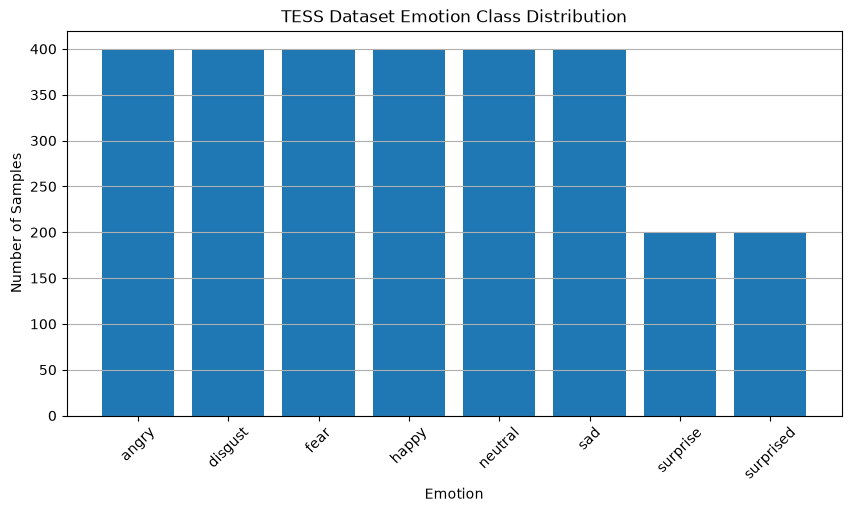

In [7]:
class_counts = df["emotion"].value_counts()


plt.figure(figsize=(10,5))


plt.bar(
    class_counts.index,
    class_counts.values
)


plt.xlabel(
    "Emotion"
)

plt.ylabel(
    "Number of Samples"
)


plt.title(
    "TESS Dataset Emotion Class Distribution"
)


plt.xticks(
    rotation=45
)


plt.grid(
    axis="y"
)


plt.show()

In [8]:
summary_df = pd.DataFrame({

    "Emotion": class_counts.index,

    "Number of Samples": class_counts.values

})


summary_df

,Emotion,Number of Samples
0,angry,400
1,disgust,400
2,fear,400
3,happy,400
4,neutral,400
5,sad,400
6,surprise,200
7,surprised,200


# Audio Sample Visualization

One sample from each emotion category is visualized using waveform and Mel spectrogram plots.

The waveform represents the amplitude variation over time, while the Mel spectrogram shows the time-frequency representation of the audio signal.

Emotion: angry
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_angry\YAF_book_angry.wav


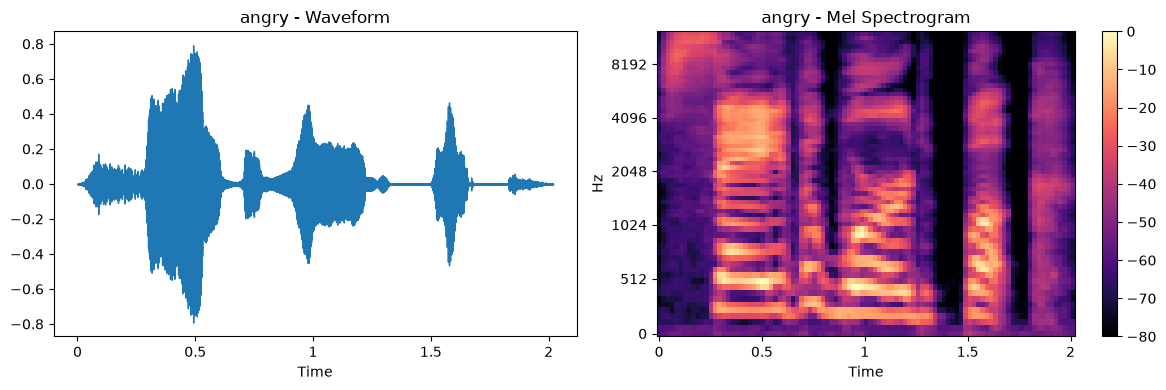

Emotion: disgust
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_disgust\YAF_book_disgust.wav


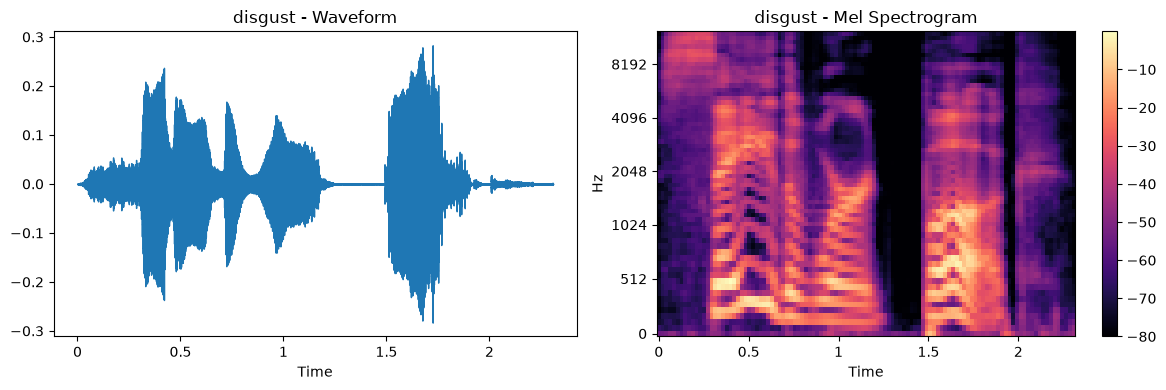

Emotion: fear
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_fear\YAF_book_fear.wav


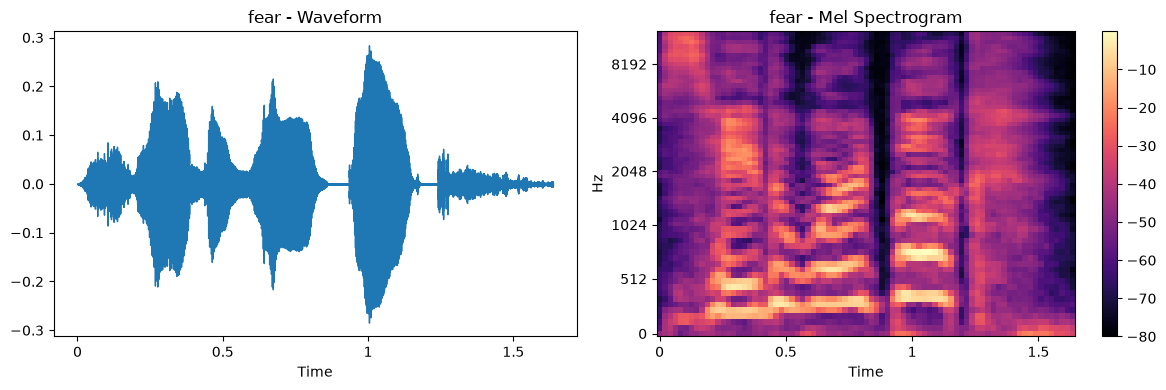

Emotion: happy
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_happy\YAF_book_happy.wav


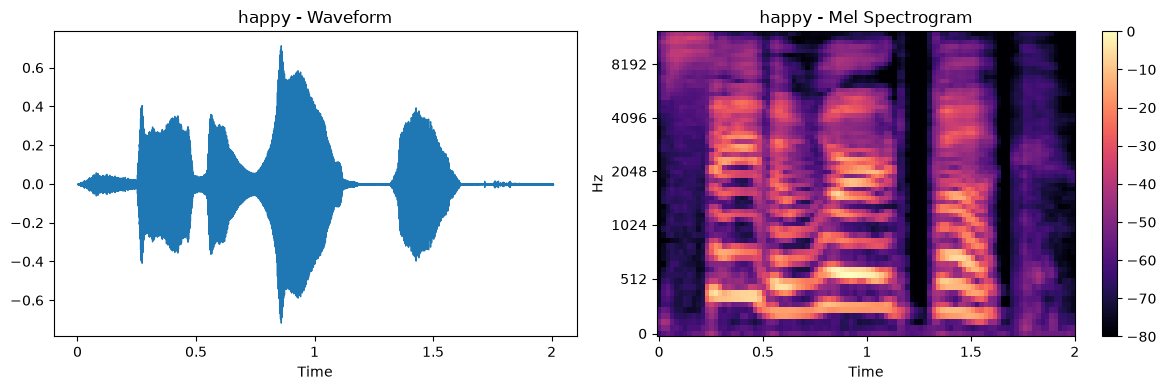

Emotion: neutral
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_neutral\YAF_book_neutral.wav


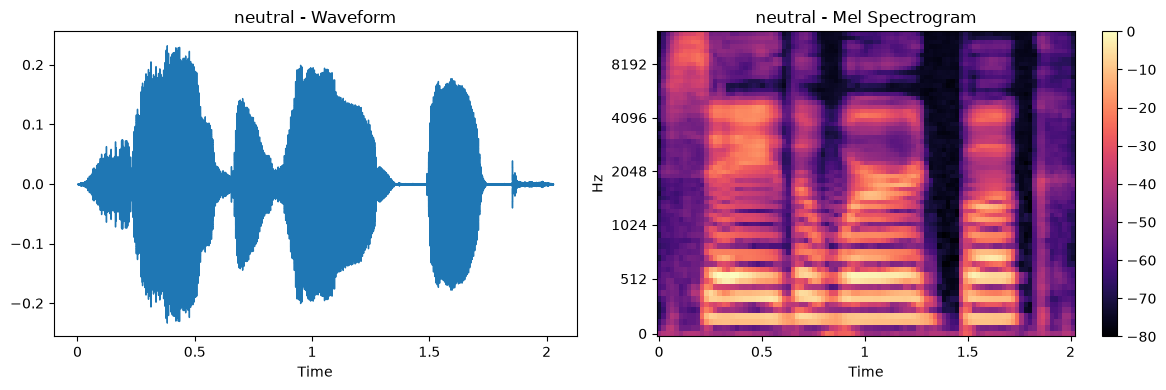

Emotion: sad
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_sad\YAF_book_sad.wav


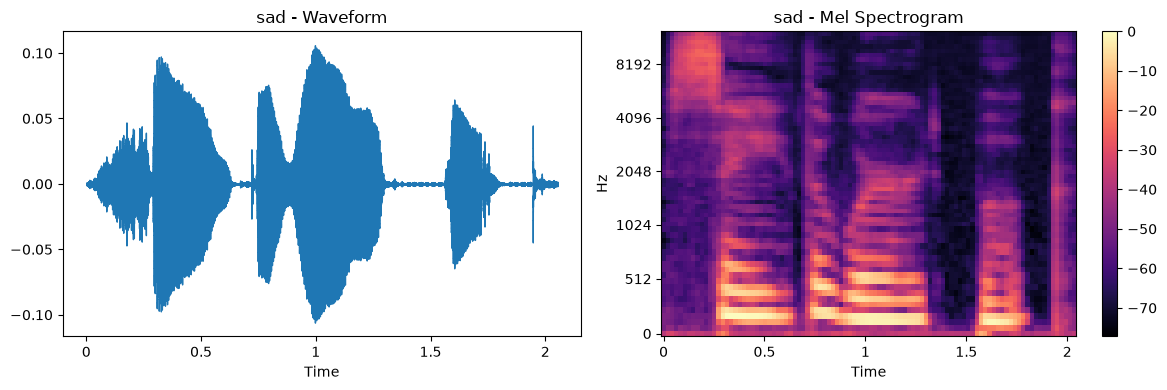

Emotion: surprise
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\OAF_Pleasant_surprise\OAF_luck_ps.wav


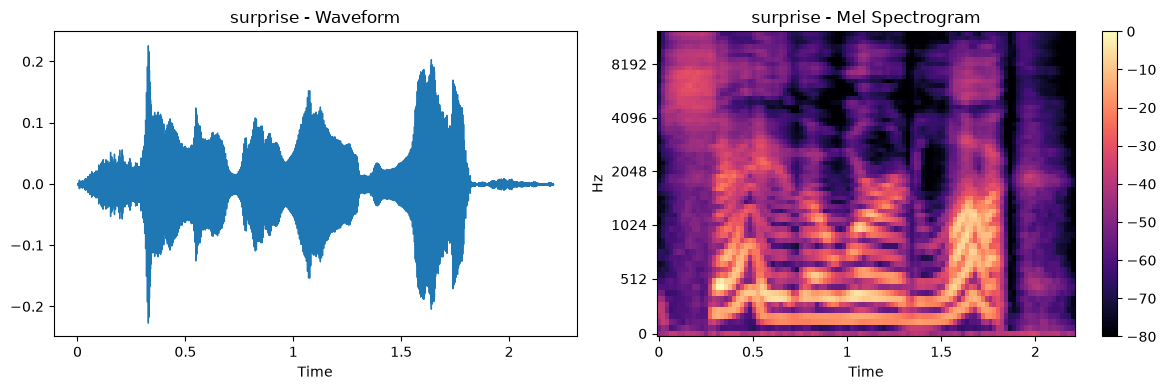

Emotion: surprised
File: D:\onboarding-audio\task5\archive\TESS Toronto emotional speech set data\YAF_pleasant_surprised\YAF_luck_ps.wav


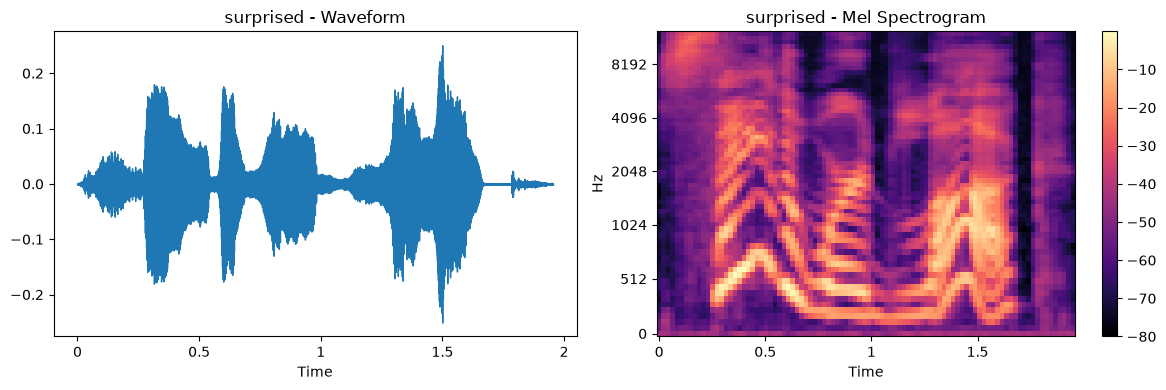

In [9]:
from IPython.display import Audio, display


sample_files = []


for emotion in classes:

    sample = df[
        df["emotion"] == emotion
    ].sample(
        1,
        random_state=42
    )


    sample_files.append(
        (
            emotion,
            sample.iloc[0]["path"]
        )
    )



for emotion, path in sample_files:


    print("="*40)

    print(
        "Emotion:",
        emotion
    )

    print(
        "File:",
        path
    )


    display(
        Audio(path)
    )


    y, sr = librosa.load(
        path,
        sr=None
    )


    plt.figure(figsize=(12,4))


    # Waveform

    plt.subplot(
        1,
        2,
        1
    )


    librosa.display.waveshow(
        y,
        sr=sr
    )


    plt.title(
        emotion + " - Waveform"
    )


    # Mel Spectrogram

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=64
    )


    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )


    plt.subplot(
        1,
        2,
        2
    )


    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )


    plt.colorbar()


    plt.title(
        emotion + " - Mel Spectrogram"
    )


    plt.tight_layout()

    plt.show()

# Step 5: Audio Preprocessing and MFCC Feature Extraction

Audio signals cannot be directly provided to an LSTM model.

Therefore, each audio file is processed using the following steps:

1. Load audio waveform
2. Convert to mono audio
3. Resample to 16 kHz
4. Extract MFCC features
5. Normalize the features

MFCC features preserve important spectral characteristics of speech while representing the audio as a time sequence suitable for LSTM input.

In [11]:
class AudioPreprocessor:


    def __init__(
        self,
        sr=16000,
        n_mfcc=40,
        duration=3
    ):

        self.sr = sr

        self.n_mfcc = n_mfcc

        self.samples = int(
            sr * duration
        )



    def load_audio(self, path):

        y, sr = librosa.load(
            path,
            sr=self.sr,
            mono=True
        )


        return y



    def pad_or_truncate(self, y):


        if len(y) < self.samples:

            y = np.pad(
                y,
                (
                    0,
                    self.samples-len(y)
                )
            )


        else:

            y = y[:self.samples]


        return y



    def extract_mfcc(self, y):


        mfcc = librosa.feature.mfcc(
            y=y,
            sr=self.sr,
            n_mfcc=self.n_mfcc
        )


        # Convert:
        # (mfcc, time)
        # to
        # (time, mfcc)

        mfcc = mfcc.T


        return mfcc



    def process(self,path):


        y = self.load_audio(path)


        y = self.pad_or_truncate(
            y
        )


        mfcc = self.extract_mfcc(
            y
        )


        return mfcc

In [12]:
processor = AudioPreprocessor()


sample_path = df.iloc[0]["path"]


features = processor.process(
    sample_path
)


print(
    "MFCC Shape:",
    features.shape
)

MFCC Shape: (94, 40)


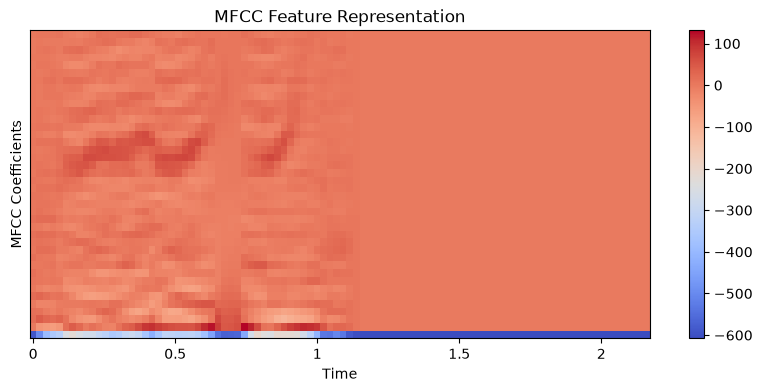

In [13]:
plt.figure(figsize=(10,4))


librosa.display.specshow(
    features.T,
    x_axis="time"
)


plt.colorbar()


plt.title(
    "MFCC Feature Representation"
)


plt.ylabel(
    "MFCC Coefficients"
)


plt.show()

# Step 6: Dataset and DataLoader

The emotion labels are converted into numerical values for model training.

The dataset is divided into:
- Training set
- Validation set
- Testing set

A custom PyTorch Dataset is created to load MFCC feature sequences and corresponding emotion labels.

In [15]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()


df["label"] = encoder.fit_transform(
    df["emotion"]
)


num_classes = len(
    encoder.classes_
)


print(
    "Number of Classes:",
    num_classes
)


print(
    encoder.classes_
)

Number of Classes: 8
['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise' 'surprised']


In [16]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)


train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"]
)



print(
    "Training Samples:",
    len(train_df)
)


print(
    "Validation Samples:",
    len(val_df)
)


print(
    "Testing Samples:",
    len(test_df)
)

Training Samples: 2023
Validation Samples: 357
Testing Samples: 420


In [17]:
class EmotionDataset(Dataset):


    def __init__(
        self,
        dataframe,
        processor
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.processor = processor



    def __len__(self):

        return len(
            self.df
        )



    def __getitem__(
        self,
        idx
    ):


        row = self.df.iloc[idx]


        path = row["path"]


        label = row["label"]



        mfcc = self.processor.process(
            path
        )


        mfcc = torch.tensor(
            mfcc,
            dtype=torch.float32
        )


        label = torch.tensor(
            label,
            dtype=torch.long
        )


        return mfcc, label

In [18]:
processor = AudioPreprocessor(
    sr=16000,
    n_mfcc=40,
    duration=3
)



train_dataset = EmotionDataset(
    train_df,
    processor
)


val_dataset = EmotionDataset(
    val_df,
    processor
)


test_dataset = EmotionDataset(
    test_df,
    processor
)

In [19]:
BATCH_SIZE = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [20]:
x,y = next(iter(train_loader))


print(
    "Feature batch shape:",
    x.shape
)


print(
    "Label batch shape:",
    y.shape
)

Feature batch shape: torch.Size([32, 94, 40])
Label batch shape: torch.Size([32])


In [21]:
x,y = next(iter(train_loader))


print(
    "Feature batch shape:",
    x.shape
)


print(
    "Label batch shape:",
    y.shape
)

Feature batch shape: torch.Size([32, 94, 40])
Label batch shape: torch.Size([32])


In [22]:
class EmotionLSTM(nn.Module):


    def __init__(
        self,
        input_size=40,
        hidden_size=128,
        num_layers=2,
        num_classes=7,
        dropout=0.3
    ):

        super(
            EmotionLSTM,
            self
        ).__init__()



        self.hidden_size = hidden_size

        self.num_layers = num_layers



        self.lstm = nn.LSTM(

            input_size=input_size,

            hidden_size=hidden_size,

            num_layers=num_layers,

            batch_first=True,

            dropout=dropout

        )



        self.dropout = nn.Dropout(
            dropout
        )



        self.fc = nn.Linear(

            hidden_size,

            num_classes

        )



    def forward(self,x):


        # LSTM output
        output, (hidden, cell) = self.lstm(x)



        # Take last time step output

        out = output[:,-1,:]



        out = self.dropout(
            out
        )


        out = self.fc(
            out
        )


        return out

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print(
    "Using device:",
    device
)



model = EmotionLSTM(
    input_size=40,
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes
)



model = model.to(device)


print(model)

Using device: cpu
EmotionLSTM(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)


In [24]:
x,y = next(iter(train_loader))


x = x.to(device)


output = model(x)



print(
    "Input Shape:",
    x.shape
)


print(
    "Output Shape:",
    output.shape
)

Input Shape: torch.Size([32, 94, 40])
Output Shape: torch.Size([32, 8])


# Step 8: LSTM Model Training

The LSTM model is trained using:

- Cross Entropy Loss for multi-class classification
- Adam optimizer
- Learning rate scheduler
- Automatic Mixed Precision (AMP) for faster GPU training

Training and validation performance are monitored to evaluate model generalization.

In [34]:
BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [35]:
class EmotionLSTM(nn.Module):

    def __init__(
        self,
        input_size=40,
        hidden_size=128,
        num_classes=7
    ):

        super().__init__()


        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )


        self.dropout = nn.Dropout(0.3)


        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )


    def forward(self,x):

        output, (hidden, cell) = self.lstm(x)


        # last time step
        x = output[:,-1,:]


        x = self.dropout(x)


        x = self.fc(x)


        return x

In [36]:
device = torch.device("cpu")


model = EmotionLSTM(
    input_size=40,
    hidden_size=128,
    num_classes=num_classes
)


model = model.to(device)


print(model)

EmotionLSTM(
  (lstm): LSTM(40, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)


In [37]:
import time


criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


EPOCHS = 15


train_losses = []

train_accs = []

val_accs = []

In [38]:
def evaluate(model, loader):

    model.eval()


    correct = 0
    total = 0


    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)


            output = model(x)


            pred = output.argmax(
                dim=1
            )


            correct += (
                pred == y
            ).sum().item()


            total += y.size(0)


    return correct / total

In [39]:
start_time = time.time()


for epoch in range(EPOCHS):


    model.train()


    running_loss = 0

    correct = 0

    total = 0



    for x,y in train_loader:


        x = x.to(device)

        y = y.to(device)



        optimizer.zero_grad()



        output = model(x)



        loss = criterion(
            output,
            y
        )



        loss.backward()


        optimizer.step()



        running_loss += loss.item()



        pred = output.argmax(
            dim=1
        )


        correct += (
            pred == y
        ).sum().item()


        total += y.size(0)



    train_loss = (
        running_loss / len(train_loader)
    )


    train_acc = (
        correct / total
    )


    val_acc = evaluate(
        model,
        val_loader
    )


    train_losses.append(
        train_loss
    )


    train_accs.append(
        train_acc
    )


    val_accs.append(
        val_acc
    )


    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )


print(
    "Training Time:",
    round(time.time()-start_time,2),
    "seconds"
)

Epoch [1/15] Loss: 1.9878 Train Acc: 0.2150 Val Acc: 0.4790
Epoch [2/15] Loss: 1.8056 Train Acc: 0.4152 Val Acc: 0.7479
Epoch [3/15] Loss: 1.5340 Train Acc: 0.6307 Val Acc: 0.8123
Epoch [4/15] Loss: 1.2346 Train Acc: 0.7711 Val Acc: 0.9020
Epoch [5/15] Loss: 0.9257 Train Acc: 0.8685 Val Acc: 0.9132
Epoch [6/15] Loss: 0.6355 Train Acc: 0.9343 Val Acc: 0.9888
Epoch [7/15] Loss: 0.4102 Train Acc: 0.9713 Val Acc: 0.9944
Epoch [8/15] Loss: 0.2629 Train Acc: 0.9901 Val Acc: 0.9944
Epoch [9/15] Loss: 0.1707 Train Acc: 0.9926 Val Acc: 0.9972
Epoch [10/15] Loss: 0.1148 Train Acc: 0.9965 Val Acc: 0.9944
Epoch [11/15] Loss: 0.0766 Train Acc: 0.9985 Val Acc: 1.0000
Epoch [12/15] Loss: 0.0585 Train Acc: 0.9975 Val Acc: 1.0000
Epoch [13/15] Loss: 0.0442 Train Acc: 0.9995 Val Acc: 1.0000
Epoch [14/15] Loss: 0.0394 Train Acc: 0.9985 Val Acc: 1.0000
Epoch [15/15] Loss: 0.0306 Train Acc: 0.9985 Val Acc: 1.0000
Training Time: 266.96 seconds


# Step 9: Testing and Evaluation

The trained LSTM model is evaluated on the unseen test dataset.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help measure the model's ability to correctly classify different emotional states.

In [43]:
model.eval()


all_preds = []

all_labels = []


with torch.no_grad():

    for x,y in test_loader:


        x = x.to(device)

        y = y.to(device)



        output = model(x)


        predictions = torch.argmax(
            output,
            dim=1
        )


        all_preds.extend(
            predictions.cpu().numpy()
        )


        all_labels.extend(
            y.cpu().numpy()
        )



print(
    "Predictions Generated"
)

Predictions Generated


In [44]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)


precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)


recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)


f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print(
    "Accuracy:",
    round(accuracy,4)
)


print(
    "Precision:",
    round(precision,4)
)


print(
    "Recall:",
    round(recall,4)
)


print(
    "F1 Score:",
    round(f1,4)
)

Accuracy: 0.9976
Precision: 0.996
Recall: 0.9979
F1 Score: 0.9969


## Classification Report

The classification report provides precision, recall, and F1-score for each individual emotion class.

In [46]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        60
     disgust       1.00      1.00      1.00        60
        fear       1.00      1.00      1.00        60
       happy       1.00      0.98      0.99        60
     neutral       1.00      1.00      1.00        60
         sad       1.00      1.00      1.00        60
    surprise       0.97      1.00      0.98        30
   surprised       1.00      1.00      1.00        30

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



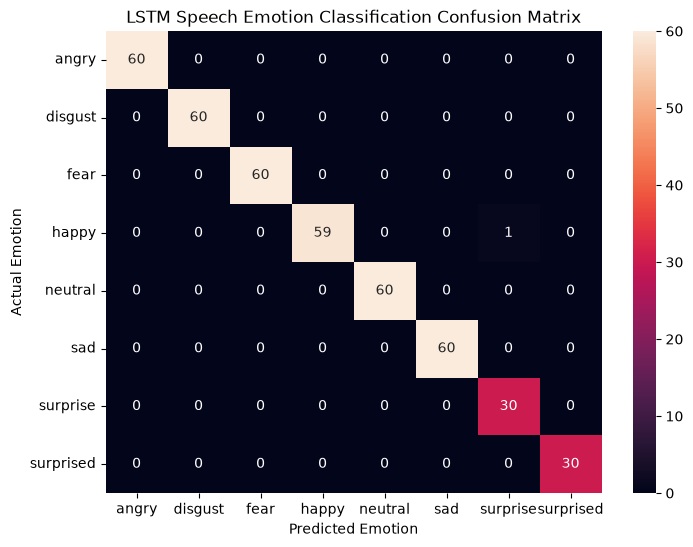

In [47]:
cm = confusion_matrix(
    all_labels,
    all_preds
)


plt.figure(
    figsize=(8,6)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)


plt.xlabel(
    "Predicted Emotion"
)


plt.ylabel(
    "Actual Emotion"
)


plt.title(
    "LSTM Speech Emotion Classification Confusion Matrix"
)


plt.show()